In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv('http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv', 
                 parse_dates = ['time'], index_col='id')
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type
id,,,,,,,,,,,,,,
ak11155107,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
nn00436847,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
ak11151142,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
ak11151135,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
ci37171541,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake


In [3]:
df['country'] = df.place.str.split(', ').str[-1]

In [4]:
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type,country
id,,,,,,,,,,,,,,,
ak11155107,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake,Alaska
nn00436847,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake,Nevada
ak11151142,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake,Alaska
ak11151135,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake,Alaska
ci37171541,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake,Mexico


In [5]:
df_all = df
df_small = df[df.mag<4]
df = df[df.mag>=4]

In [ ]:
list(df.groupby('country').groups.keys())

<Axes: xlabel='country'>

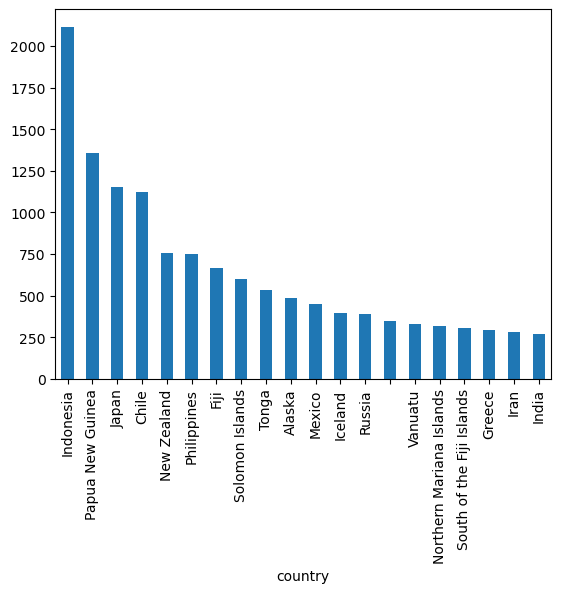

In [6]:
df.groupby('country').mag.count().nlargest(20).plot(kind='bar')

In [9]:
df.groupby('country')

In [10]:
gb = df.groupby('country') 

In [11]:
gb

In [12]:
gb.count()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type
country,,,,,,,,,,,,,,
,344,344,344,344,344,344,0,344,344,344,344,344,344,344
Afghanistan,147,147,147,147,147,147,0,147,147,147,147,147,147,147
Alaska,486,486,486,486,486,486,14,225,178,486,486,486,486,486
Albania,14,14,14,14,14,14,0,6,6,14,14,14,14,14
Algeria,15,15,15,15,15,15,0,15,15,15,15,15,15,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zambia,7,7,7,7,7,7,0,7,7,7,7,7,7,7
north of Ascension Island,1,1,1,1,1,1,0,1,1,1,1,1,1,1
northern Mid-Atlantic Ridge,1,1,1,1,1,1,0,1,1,1,1,1,1,1


In [13]:
len(gb)

269

In [14]:
gb.groups.keys()

dict_keys(['', 'Afghanistan', 'Alaska', 'Albania', 'Algeria', 'American Samoa', 'Angola', 'Anguilla', 'Antarctica', 'Argentina', 'Arizona', 'Aruba', 'Ascension Island region', 'Australia', 'Azerbaijan', 'Azores Islands region', 'Azores-Cape St. Vincent Ridge', 'Balleny Islands region', 'Banda Sea', 'Bangladesh', 'Barbados', 'Barbuda', 'Bay of Bengal', 'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Bouvet Island', 'Bouvet Island region', 'Brazil', 'British Indian Ocean Territory', 'British Virgin Islands', 'Burma', 'Burundi', 'California', 'Canada', 'Cape Verde', 'Carlsberg Ridge', 'Cayman Islands', 'Celebes Sea', 'Central East Pacific Rise', 'Central Mid-Atlantic Ridge', 'Chagos Archipelago region', 'Chile', 'China', 'Christmas Island', 'Colombia', 'Comoros', 'Cook Islands', 'Costa Rica', 'Crozet Islands region', 'Cuba', 'Cyprus', 'Davis Strait', 'Democratic Republic of the Congo', 'Djibouti', 'Dominica', 'Dominican Republic', 'Drake Passage', 'East Timor', 'East central Pa

In [ ]:
list(gb.groups.keys())

In [16]:
gb.get_group('Chile')

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type,country
id,,,,,,,,,,,,,,,
usc000mqlq,2014-01-31 20:00:16.000,-33.6550,-71.9810,25.10,4.5,mb,NaN,NaN,NaN,1.63,us,2014-04-08T01:43:19.000Z,"34km WSW of San Antonio, Chile",earthquake,Chile
usc000mql6,2014-01-31 13:48:23.000,-18.0690,-69.6630,149.10,4.3,mb,NaN,NaN,NaN,1.77,us,2014-04-08T01:43:18.000Z,"17km NW of Putre, Chile",earthquake,Chile
usc000mqk8,2014-01-30 14:20:56.560,-19.6118,-70.9487,15.16,4.1,mb,NaN,159.0,1.227,1.34,us,2014-04-08T01:43:17.000Z,"107km NW of Iquique, Chile",earthquake,Chile
usc000mdi2,2014-01-30 10:02:14.000,-32.1180,-71.7860,25.70,4.5,mwr,NaN,NaN,NaN,1.10,us,2015-01-30T21:28:21.955Z,"64km NW of La Ligua, Chile",earthquake,Chile
usc000mqeh,2014-01-29 18:58:23.000,-18.6610,-69.6440,123.10,4.8,mb,NaN,NaN,NaN,1.52,us,2014-04-08T01:43:16.000Z,"51km S of Putre, Chile",earthquake,Chile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
usb000t2cx,2014-12-03 02:29:00.460,-19.9895,-70.9677,11.86,4.9,mww,NaN,99.0,0.885,1.15,us,2015-02-28T02:16:05.040Z,"89km WNW of Iquique, Chile",earthquake,Chile
usc000t7cp,2014-12-02 20:23:57.530,-19.7460,-71.0203,35.43,4.0,mb,NaN,169.0,0.858,0.70,us,2015-02-24T00:35:16.040Z,"105km WNW of Iquique, Chile",earthquake,Chile
usb000t208,2014-12-02 03:56:47.000,-20.2790,-71.0550,33.00,4.6,mwr,NaN,NaN,NaN,0.37,us,2015-02-24T00:35:15.040Z,"95km W of Iquique, Chile",earthquake,Chile


<Axes: xlabel='id'>

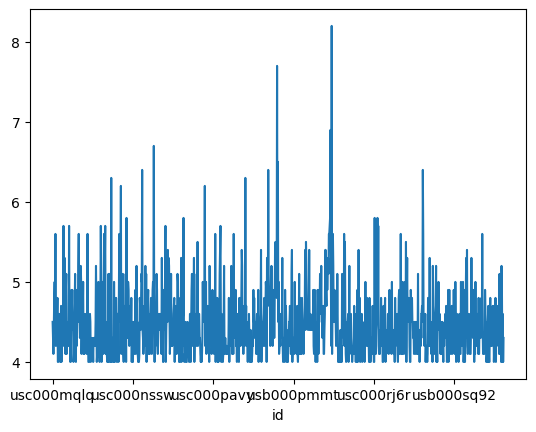

In [17]:
df_Chile = gb.get_group('Chile')
df_Chile.mag.plot()

In [21]:
gb.get_group('New Mexico')

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type,country
id,,,,,,,,,,,,,,,
usb000rvqp,2014-06-29 06:10:05.720,32.5649,-109.1001,5.00,4.0,mwr,NaN,100.0,1.111,0.51,us,2015-01-29T17:42:11.523Z,"43km WNW of Lordsburg, New Mexico",earthquake,New Mexico
usc000rnfe,2014-06-29 04:59:35.390,32.5822,-109.1682,6.44,5.3,mww,NaN,54.0,1.169,0.69,us,2015-04-07T22:34:32.489Z,"50km WNW of Lordsburg, New Mexico",earthquake,New Mexico


In [22]:
gb2 = df.groupby(['country','magType'])

In [24]:
gb2.count().head(30)

time  latitude  longitude  depth  mag  nst  gap  dmin  \
country        magType                                                          
               mb        329       329        329    329  329    0  329   329   
               mwb         8         8          8      8    8    0    8     8   
               mww         7         7          7      7    7    0    7     7   
Afghanistan    mb        141       141        141    141  141    0  141   141   
               mwb         1         1          1      1    1    0    1     1   
               mwc         1         1          1      1    1    0    1     1   
               mwr         2         2          2      2    2    0    2     2   
               mww         2         2          2      2    2    0    2     2   
Alaska         mb        391       391        391    391  391    0  198   161   
               ml         78        78         78     78   78   14   14     4   
               mwb         5         5          5      5    5    0    5     5   
               mwr         4         4          4      4    4    0    2     2   
               mww         8         8          8      8    8    0    6     6   
Albania        mb          8         8          8      8    8    0    4     4   
               ml          2         2          2      2    2    0    0     0   
               mwr         4         4          4      4    4    0    2     2   
Algeria        mb         12        12         12     12   12    0   12    12   
               ml          1         1          1      1    1    0    1     1   
               mwr         1         1          1      1    1    0    1     1   
               mww         1         1          1      1    1    0    1     1   
American Samoa mb          1         1          1      1    1    0    1     1   
Angola         mb          1         1          1      1    1    0    1     1   
Anguilla       mb          1         1          1      1    1    0    1     1   
               md          1         1          1      1    1    0    0     0   
               mwr         2         2          2      2    2    0    2     2   
Antarctica     mb         10        10         10     10   10    0   10    10   
Argentina      mb        175       175        175    175  175    0  136   136   
               md          2         2          2      2    2    0    0     0   
               ml          3         3          3      3    3    0    0     0   
               mwr         2         2          2      2    2    0    0     0   

                        rms  net  updated  place  type  
country        magType                                  
               mb       329  329      329    329   329  
               mwb        8    8        8      8     8  
               mww        7    7        7      7     7  
Afghanistan    mb       141  141      141    141   141  
               mwb        1    1        1      1     1  
               mwc        1    1        1      1     1  
               mwr        2    2        2      2     2  
               mww        2    2        2      2     2  
Alaska         mb       391  391      391    391   391  
               ml        78   78       78     78    78  
               mwb        5    5        5      5     5  
               mwr        4    4        4      4     4  
               mww        8    8        8      8     8  
Albania        mb         8    8        8      8     8  
               ml         2    2        2      2     2  
               mwr        4    4        4      4     4  
Algeria        mb        12   12       12     12    12  
               ml         1    1        1      1     1  
               mwr        1    1        1      1     1  
               mww        1    1        1      1     1  
American Samoa mb         1    1        1      1     1  
Angola         mb         1    1        1      1     1  
Anguilla       mb         1    1        1      1     1  
      

In [25]:
gb

In [ ]:
gb.aggregate('max').head(30)

In [29]:
gb['mag'].aggregate('max').head(30)

country
                                 6.9
Afghanistan                      5.6
Alaska                           7.9
Albania                          5.0
Algeria                          5.5
American Samoa                   4.6
Angola                           4.1
Anguilla                         5.0
Antarctica                       4.8
Argentina                        6.2
Arizona                          4.7
Aruba                            4.6
Ascension Island region          5.1
Australia                        4.7
Azerbaijan                       5.5
Azores Islands region            5.4
Azores-Cape St. Vincent Ridge    4.6
Balleny Islands region           6.2
Banda Sea                        5.3
Bangladesh                       4.3
Barbados                         6.5
Barbuda                          4.3
Bay of Bengal                    4.4
Bermuda                          4.2
Bhutan                           4.2
Bolivia                          5.6
Bosnia and Herzegovina        

In [30]:
gb.mag.aggregate('max').nlargest(10)

country
Chile                         8.2
Alaska                        7.9
Solomon Islands               7.6
Papua New Guinea              7.5
El Salvador                   7.3
Mexico                        7.2
Fiji                          7.1
Indonesia                     7.1
Southern East Pacific Rise    7.0
                              6.9
Name: mag, dtype: float64

In [31]:
gb.mag.aggregate('mean').nlargest(10)

country
South Napa Earthquake          6.020000
Bouvet Island region           5.750000
South Georgia Island region    5.450000
Barbados                       5.400000
Easter Island region           5.162500
Malawi                         5.100000
Drake Passage                  5.033333
North Korea                    5.000000
Saint Lucia                    5.000000
Pacific-Antarctic Ridge        4.923214
Name: mag, dtype: float64

In [33]:
gb.mag.aggregate(['min','max','mean']).head(20)

,min,max,mean
country,,,
,4.0,6.9,4.572384
Afghanistan,4.0,5.6,4.340816
Alaska,4.0,7.9,4.430247
Albania,4.0,5.0,4.335714
Algeria,4.0,5.5,4.466667
American Samoa,4.6,4.6,4.600000
Angola,4.1,4.1,4.100000
Anguilla,4.0,5.0,4.525000
Antarctica,4.1,4.8,4.480000


<Axes: xlabel='country'>

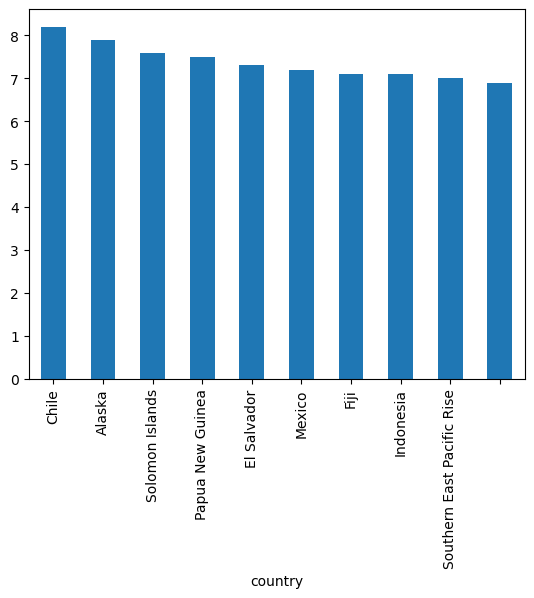

In [34]:
gb.mag.aggregate('max').nlargest(10).plot(kind='bar')

<Axes: xlabel='country'>

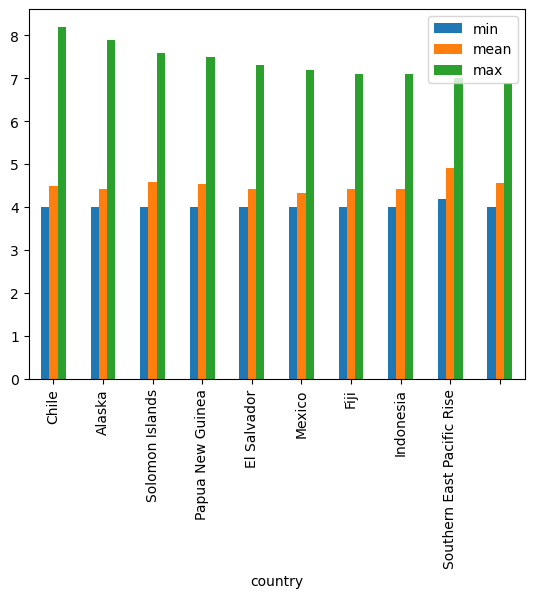

In [35]:
gb.mag.aggregate(['min','mean','max']).nlargest(10,'max').plot(kind='bar')

In [37]:
def standardize(x):
    return ((x - x.mean())/x.std())

In [41]:
mag_apply = gb.mag.apply(standardize)
mag_apply.tail(50)

country                         id        
Western Indian-Antarctic Ridge  usc000t9tt    0.562468
                                usc000td8u   -0.449975
                                usc000td52   -1.462417
                                usc000tclj   -0.112494
                                usc000t4rc    1.912392
Yemen                           usc000n4ye   -1.353454
                                usc000rc1s    0.970659
                                usc000rmbg    0.970659
                                usc000rmmz   -0.888632
                                usc000rlqa   -0.423809
                                usc000rlqc   -0.423809
                                usc000rlqd    0.041014
                                usc000rn25    0.041014
                                usc000rn2a   -0.423809
                                usc000rcga    0.041014
                                usc000rit9   -1.353454
                                usc000rit8   -0.423809
                      

In [44]:
import urllib
import pandas as pd

header_url = 'ftp://ftp.ncdc.noaa.gov/pub/data/uscrn/products/daily01/HEADERS.txt'
with urllib.request.urlopen(header_url) as response:
    data = response.read().decode('utf-8')
lines = data.split('\n')
headers = lines[1].split(' ')

ftp_base = 'ftp://ftp.ncdc.noaa.gov/pub/data/uscrn/products/daily01/'
dframes = []
for year in range(2016, 2019):
    data_url = f'{year}/CRND0103-{year}-NY_Millbrook_3_W.txt'               
    df = pd.read_csv(ftp_base + data_url, parse_dates=[1],
                     names=headers, header=None, sep='\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')

In [45]:
df

,WBANNO,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,SOLARAD_DAILY,...,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY,
LST_DATE,,,,,,,,,,,,,,,,,,,,,
2016-01-01,64756,2.422,-73.74,41.79,3.4,-0.5,1.5,1.3,0.0,1.69,...,0.233,0.204,0.155,0.147,4.2,4.4,5.1,6.0,7.6,NaN
2016-01-02,64756,2.422,-73.74,41.79,2.9,-3.6,-0.4,-0.3,0.0,6.25,...,0.227,0.199,0.152,0.144,2.8,3.1,4.2,5.7,7.4,NaN
2016-01-03,64756,2.422,-73.74,41.79,5.1,-1.8,1.6,1.1,0.0,5.69,...,0.223,0.196,0.151,0.141,2.6,2.8,3.8,5.2,7.2,NaN
2016-01-04,64756,2.422,-73.74,41.79,0.5,-14.4,-6.9,-7.5,0.0,9.17,...,0.220,0.194,0.148,0.139,1.7,2.1,3.4,4.9,6.9,NaN
2016-01-05,64756,2.422,-73.74,41.79,-5.2,-15.5,-10.3,-11.7,0.0,9.34,...,0.213,0.191,0.148,0.138,0.4,0.9,2.4,4.3,6.6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-27,64756,2.622,-73.74,41.79,2.5,-2.1,0.2,0.3,0.0,7.50,...,0.275,0.248,0.191,0.192,1.3,1.4,1.9,3.2,4.7,NaN
2018-12-28,64756,2.622,-73.74,41.79,11.6,1.9,6.8,7.6,11.5,0.45,...,0.295,0.261,0.193,0.191,2.9,2.7,2.5,3.1,4.5,NaN
2018-12-29,64756,2.622,-73.74,41.79,11.3,-2.1,4.6,6.3,0.0,4.89,...,0.295,0.270,0.208,0.191,4.5,4.4,4.0,3.8,4.5,NaN


<Axes: xlabel='LST_DATE'>

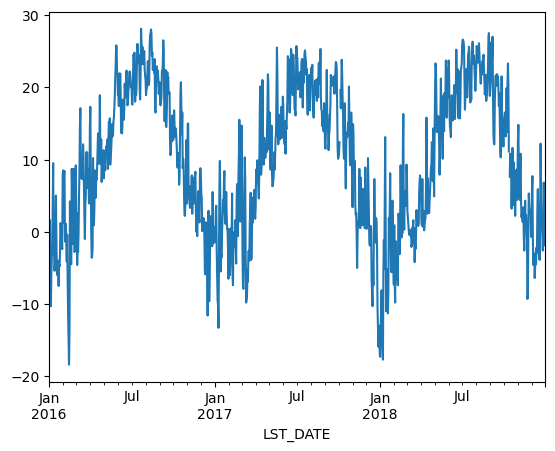

In [46]:
df.T_DAILY_MEAN.plot()

In [47]:
df.groupby(df.index.month).mean(numeric_only=True)

,WBANNO,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,SOLARAD_DAILY,...,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY,
LST_DATE,,,,,,,,,,,,,,,,,,,,,
1,64756.0,2.488667,-73.74,41.79,2.924731,-7.122581,-2.100000,-1.905376,2.478495,5.812258,...,0.240250,0.200698,0.153645,0.160859,0.150538,0.248387,0.788172,1.766667,3.364516,NaN
2,64756.0,2.487882,-73.74,41.79,6.431765,-5.015294,0.712941,1.022353,4.077647,8.495882,...,0.247714,0.210044,0.159153,0.163889,1.216471,1.169412,1.278824,1.617647,2.442353,NaN
3,64756.0,2.488667,-73.74,41.79,7.953763,-3.035484,2.455914,2.643011,2.788172,13.211290,...,0.228612,0.203634,0.157796,0.160366,3.450538,3.400000,3.372043,3.480645,3.777419,NaN
4,64756.0,2.488667,-73.74,41.79,14.793333,1.816667,8.302222,8.574444,2.396667,15.295889,...,0.214067,0.195844,0.153878,0.158100,9.415556,9.117778,8.455556,7.618889,6.670000,NaN
5,64756.0,2.488667,-73.74,41.79,21.235484,8.460215,14.850538,15.121505,3.015054,17.288602,...,0.204796,0.187097,0.148871,0.155720,16.934409,16.640860,15.612903,14.208602,12.455914,NaN
6,64756.0,2.488667,-73.74,41.79,25.627778,11.837778,18.733333,19.026667,3.053333,21.913333,...,0.136911,0.135211,0.129422,0.152711,22.403333,22.126667,20.956667,19.448889,17.552222,NaN
7,64756.0,2.488667,-73.74,41.79,28.568817,15.536559,22.054839,22.012903,3.865591,21.570645,...,0.105806,0.095204,0.114419,0.150000,25.448387,25.318280,24.163441,22.746237,21.068817,NaN
8,64756.0,2.488667,-73.74,41.79,27.473118,15.351613,21.410753,21.378495,4.480645,18.493333,...,0.156161,0.132333,0.128796,0.158750,24.758065,24.829032,24.116129,23.325806,22.301075,NaN
9,64756.0,2.488667,-73.74,41.79,24.084444,12.032222,18.057778,17.866667,3.730000,13.625667,...,0.136900,0.126422,0.121356,0.154000,21.028889,21.168889,20.921111,20.834444,20.707778,NaN


In [48]:
df.groupby(df.index.dayofyear).mean(numeric_only=True)

,WBANNO,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,SOLARAD_DAILY,...,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY,
LST_DATE,,,,,,,,,,,,,,,,,,,,,
1,64756.0,2.488667,-73.74,41.79,-0.266667,-9.933333,-5.066667,-4.533333,0.000000,6.333333,...,0.2330,0.202667,0.155000,0.162333,1.266667,1.433333,2.100000,3.166667,4.933333,NaN
2,64756.0,2.488667,-73.74,41.79,0.500000,-10.533333,-5.033333,-4.400000,0.000000,5.270000,...,0.2270,0.195667,0.153000,0.160333,0.733333,0.966667,1.766667,3.033333,4.800000,NaN
3,64756.0,2.488667,-73.74,41.79,2.000000,-6.066667,-2.033333,-2.200000,4.366667,4.623333,...,0.2230,0.200500,0.151667,0.159000,0.666667,0.866667,1.566667,2.833333,4.700000,NaN
4,64756.0,2.488667,-73.74,41.79,1.566667,-9.266667,-3.800000,-3.766667,6.533333,4.016667,...,0.2200,0.204500,0.151333,0.158333,0.400000,0.600000,1.400000,2.700000,4.500000,NaN
5,64756.0,2.488667,-73.74,41.79,-4.266667,-12.100000,-8.133333,-9.166667,0.000000,7.660000,...,0.2130,0.203000,0.151000,0.159000,0.000000,0.233333,1.066667,2.433333,4.333333,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,64756.0,2.555333,-73.74,41.79,4.900000,-7.300000,-1.200000,-0.533333,3.833333,5.320000,...,0.2695,0.225000,0.169000,0.178000,1.033333,1.100000,1.500000,2.533333,4.266667,NaN
363,64756.0,2.555333,-73.74,41.79,2.033333,-8.300000,-3.133333,-2.866667,0.000000,5.120000,...,0.2950,0.227333,0.173667,0.177000,1.500000,1.600000,1.900000,2.700000,4.166667,NaN
364,64756.0,2.555333,-73.74,41.79,-1.500000,-9.500000,-5.500000,-5.300000,3.333333,1.603333,...,0.2860,0.224000,0.172000,0.177333,0.833333,1.000000,1.600000,2.666667,4.133333,NaN


In [50]:
monthly_climatology = df.groupby(df.index.month).aggregate({'T_DAILY_MEAN':'mean',
                                                            'T_DAILY_MAX': 'max', 
                                                            'T_DAILY_MIN':'min'})

In [51]:
monthly_climatology

,T_DAILY_MEAN,T_DAILY_MAX,T_DAILY_MIN
LST_DATE,,,
1,-2.100000,16.9,-26.0
2,0.712941,24.9,-24.7
3,2.455914,26.8,-16.5
4,8.302222,30.6,-11.3
5,14.850538,33.4,-1.6
6,18.733333,33.8,3.4
7,22.054839,35.7,8.2
8,21.410753,34.5,6.0
9,18.057778,32.7,0.3


<Axes: xlabel='LST_DATE'>

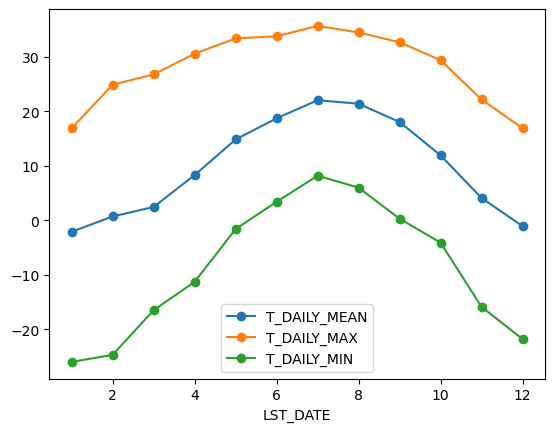

In [52]:
monthly_climatology.plot(marker='o')

<Axes: xlabel='LST_DATE'>

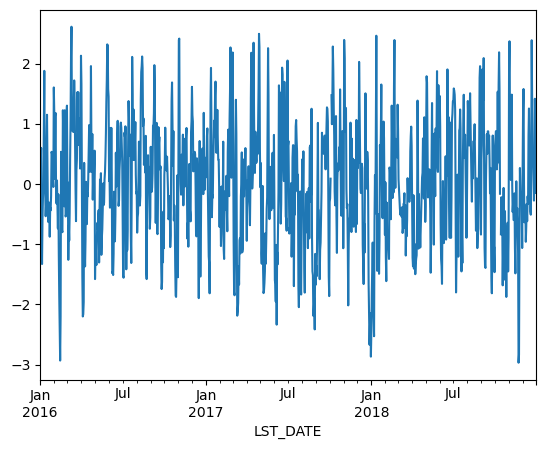

In [53]:
anomaly = df['T_DAILY_MEAN'].groupby(df.index.month).transform(standardize)
anomaly.plot()

/tmp/ipykernel_377184/3232677263.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M').mean(numeric_only=True).plot(y='T_DAILY_MEAN',marker='*')


<Axes: xlabel='LST_DATE'>

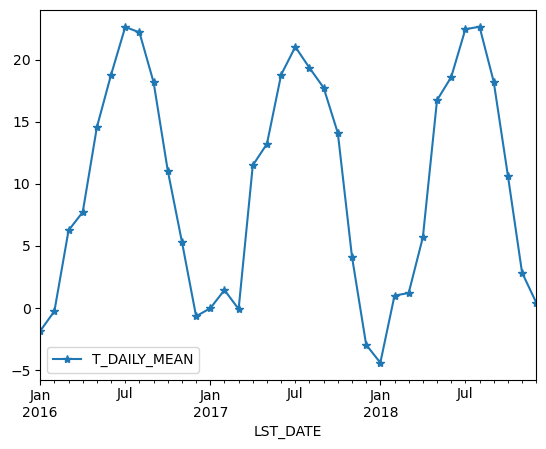

In [54]:
df.resample('M').mean(numeric_only=True).plot(y='T_DAILY_MEAN',marker='*')